In [1]:
import os
print(os.getcwd())
os.environ["NUPLAN_MAPS_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/maps")
# os.environ["NAVSIM_EXP_ROOT"] = os.path.expandvars("$HOME/Code/navsim/exp")
# os.environ["NAVSIM_DEVKIT_ROOT"] = os.path.expandvars("$HOME/Code/navsim/GTRS")
os.environ["OPENSCENE_DATA_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset")
# os.environ["NAVSIM_TRAJPDM_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/traj_pdm_v2")

from pathlib import Path

import hydra
from hydra.utils import instantiate
import matplotlib.pyplot as plt

from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig
from hydra.core.global_hydra import GlobalHydra
SPLIT = "mini"  # ["mini", "test", "trainval"]
FILTER = "all_scenes"
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()
hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
cfg = hydra.compose(config_name=FILTER)
print(cfg)
scene_filter: SceneFilter = instantiate(cfg)
# scene_filter.max_scenes = 8
openscene_data_root = Path(os.getenv("OPENSCENE_DATA_ROOT"))

scene_loader = SceneLoader(
    openscene_data_root / f"navsim_logs/{SPLIT}", # data_path
    openscene_data_root / f"sensor_blobs/{SPLIT}", # original_sensor_path
    scene_filter,
    openscene_data_root / "warmup_two_stage/sensor_blobs", # synthetic_sensor_path
    openscene_data_root / "warmup_two_stage/synthetic_scene_pickles", # synthetic_scenes_path
    sensor_config=SensorConfig.build_all_sensors(),
)

/Users/chenran/Code/e2e_av_from_scratch/phase-2 model


/var/folders/1k/q487h1g17y79bb1bj_jrhl5w0000gn/T/ipykernel_72361/3757473776.py:22: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")


{'_target_': 'navsim.common.dataclasses.SceneFilter', '_convert_': 'all', 'num_history_frames': 4, 'num_future_frames': 10, 'frame_interval': None, 'has_route': True, 'max_scenes': None, 'log_names': None, 'tokens': None}


Loading logs: 100%|██████████| 64/64 [00:02<00:00, 27.89it/s]


In [5]:
from diffusion_planner import DiffusionPlanner, cfg
from diffusion_planner_dataset import DiffusionPlannerNuplanDataset
from torch.utils.data.dataloader import DataLoader

dataset = DiffusionPlannerNuplanDataset(
    data_path = openscene_data_root / f"navsim_logs/{SPLIT}",
    cfg = cfg,
    maps_root = '/Users/chenran/Code/nuplan/dataset/maps',
    max_len = 8
)
data_loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)

In [6]:
import torch
model = DiffusionPlanner(cfg)
ckpt_path = '/Users/chenran/Code/diffusion-planner/ckpt/model.pth'
ckpt = torch.load(ckpt_path, map_location='cpu')
state_dict = ckpt['ema_state_dict']
state_dict = {
    k.replace('module.', '', 1): v
    for k, v in state_dict.items()
}
model.load_state_dict(state_dict, strict=True)
model.eval()

for idx, (token, features, targets) in enumerate(data_loader):
    op = model(features)
    if idx > 1:
        break

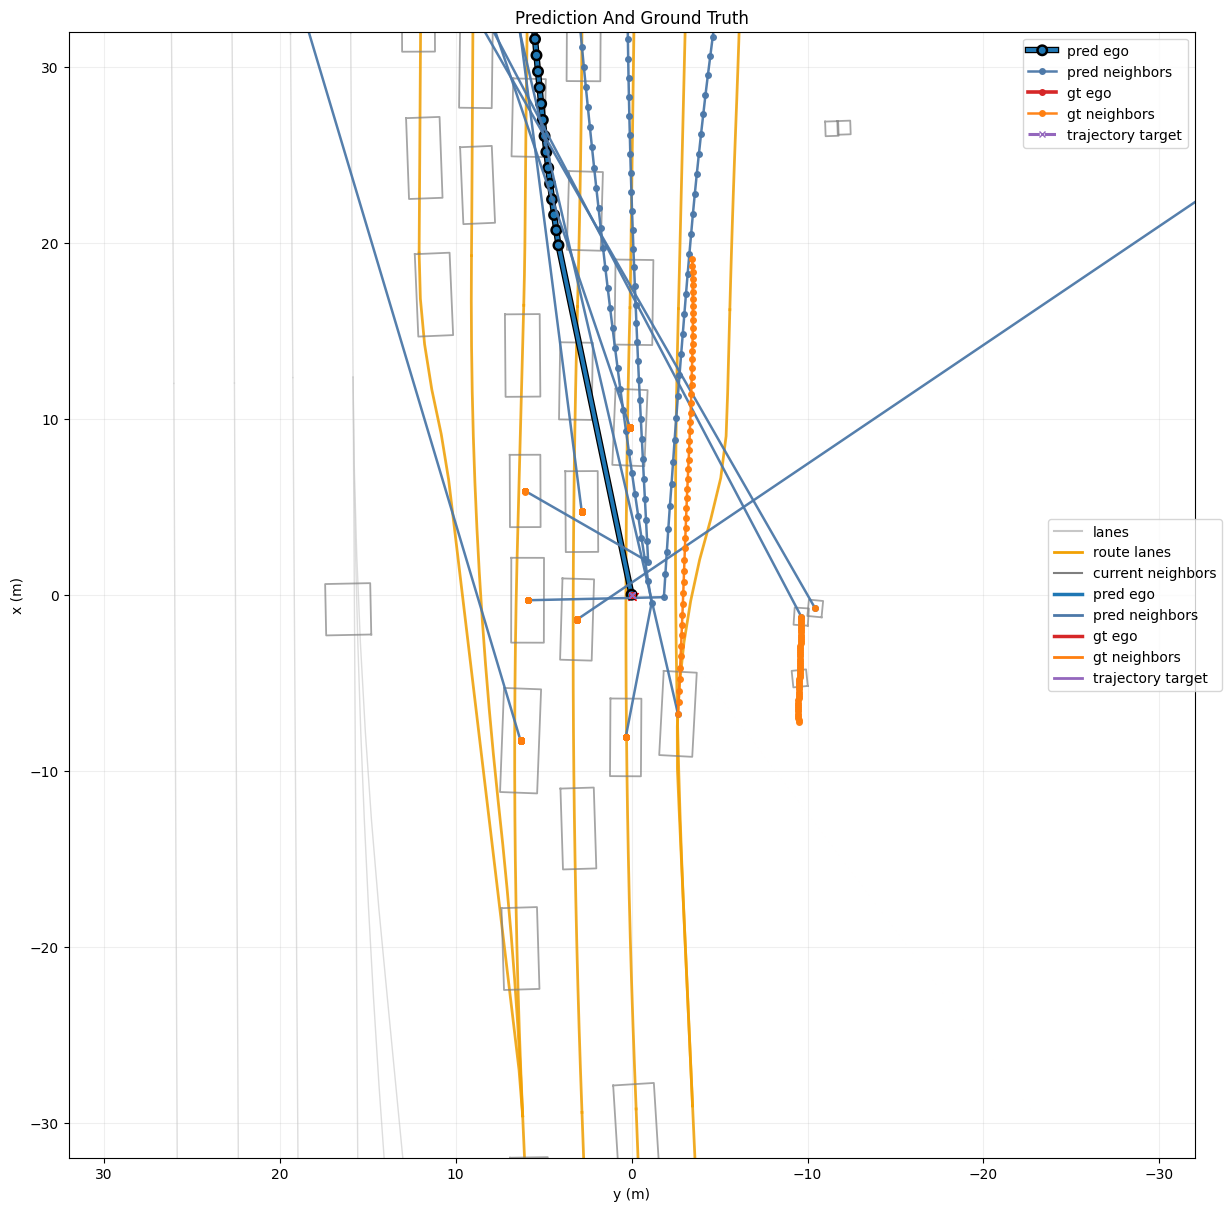

In [7]:
from visualization import show_diffusion_planner_result
show_diffusion_planner_result(op, targets, features)